### "Scratchpad" Notebook 
This notebook is for experimentation with the dataset provided to build the feature engineering logic, whereas final_FE.ipynb is the clean, finalized pipeline derived from this.

In [1]:
import pandas as pd
import numpy as np
import os
import re

In [2]:
file_path = os.path.join('..', 'data', 'raw', 'train.csv')
df = pd.read_csv(file_path)

In [3]:
df.head()

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [4]:
import pandas as pd
import re
import numpy as np
import os

# --- 1. Load the Data ---
try:
    file_path = os.path.join('..', 'data', 'raw', 'train.csv')
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("train.csv not found. Using dummy data for demonstration.")
    df = pd.DataFrame({
        'sample_id': [9259, 292686],
        'catalog_content': [
            'Item Name: Member\'s Mark Member\'s Mark, Basil, 6.25 oz',
            'Item Name: kedem Sherry Cooking Wine, 12.7 Ounce - 12 per case.'
        ],
        'image_link': ['link1', 'link2'],
        'price': [18.5, 66.49]
    })

# --- 2. Define the Final, Robust Feature Engineering Functions ---

# Define units of measure that are NOT pack counts. This is a crucial list.
UNITS_OF_MEASURE = (r'oz|ounce|o z|lb|pound|g|gram|kg|kilo|mg|milligrams|'
                    r'ml|milliliter|milliliters|l|ltr|liter|liters|cl|'
                    r'gal|gallon|qt|quart|fl oz|fluid ounce')

def extract_item_size_and_unit(text):
    """
    Finds the primary item size (weight, volume, etc.) and its associated unit.
    This function is already quite good and remains largely the same.
    """
    text = str(text)
    pattern = re.compile(r'(?P<quantity>\d*\.?\d+)\s*(?P<unit>' + UNITS_OF_MEASURE + r')', re.IGNORECASE)
    match = pattern.search(text)
    if match:
        return float(match.group('quantity')), str(match.group('unit')).strip().lower()
    return np.nan, None

def extract_pack_count_final_v2(text):
    """
    A permanently fixed, more robust pack count extraction function.
    It now correctly handles different regex patterns without conflicts.
    """
    _WORD_NUM_MAP = {"half dozen": 6, "dozen": 12, "single": 1, "pair": 2, "double": 2, "triple": 3, "trio": 3}
    def _to_float_safe(s):
        try: return float(s)
        except: return None

    if text is None: return 1.0
    s = str(text).lower().replace('×', 'x').replace(',', '')
    s = re.sub(r'[^\x00-\x7f]', ' ', s)

    # 1. Check for word-based counts first
    for k, v in _WORD_NUM_MAP.items():
        if k in s: return float(v)

    # 2. Handle the special case of multiplication (which has two numbers)
    mult_pattern = r'\b(\d{1,3}(?:\.\d+)?)\s*[x\*]\s*(\d{1,3}(?:\.\d+)?)\b'
    m = re.search(mult_pattern, s, re.IGNORECASE)
    if m:
        g1, g2 = _to_float_safe(m.group(1)), _to_float_safe(m.group(2))
        if g1 and g2: return float(g1 * g2)

    # 3. Now, handle all patterns that capture a single number
    negative_lookahead = r'(?!\s*(?:' + UNITS_OF_MEASURE.replace(' ', r'\s') + r')\b)'
    
    single_num_patterns = [
        r'\b(?:pack(?:age)?|case|box|set|bundle|combo|pk|pks|ct|count|pcs|pieces)\b[^\d]{0,6}?(\d{1,4}(?:\.\d+)?)' + negative_lookahead,
        r'\b(\d{1,4}(?:\.\d+)?)(?:\s|-)?(?:pack|pk|pks|packs|pkg|ct|count|pcs|pieces)\b' + negative_lookahead,
        r'\((?:pack(?: of)?|pk|pks|packs|count|ct)\s*(\d{1,4})\)'
    ]
    
    for p in single_num_patterns:
        m = re.search(p, s, re.IGNORECASE)
        if m:
            val = _to_float_safe(m.group(1))
            if val and val >= 1: return float(val)

    # If no explicit pack count is found, it's a single item.
    return 1.0

# --- 3. Apply the Final, Corrected Pipeline ---
print("Applying final feature engineering pipeline...")

# Step A: Extract item size and unit
temp_df = df['catalog_content'].apply(extract_item_size_and_unit).apply(pd.Series)
df['item_size'] = temp_df[0]
df['unit'] = temp_df[1]

# Step B: Extract pack count using the new, permanently fixed function
df['pack_count'] = df['catalog_content'].apply(extract_pack_count_final_v2)

# Step C: Handle missing values
df['item_size'].fillna(1.0, inplace=True)
df['unit'].fillna('unit', inplace=True)

# Step D: Create the 'total_quantity' feature
df['total_quantity'] = df['item_size'] * df['pack_count']

# Step E: Select and reorder columns
final_columns = ['sample_id', 'catalog_content', 'image_link', 'price', 
                 'item_size', 'pack_count', 'total_quantity', 'unit']
if 'price' not in df.columns:
    final_columns.remove('price')
df_final = df[final_columns]

# --- 4. Check Your Final DataFrame ---
print("\n✅ Final feature engineering complete.")


Applying final feature engineering pipeline...

✅ Final feature engineering complete.


C:\Users\nikk6\AppData\Local\Temp\ipykernel_25444\3463830530.py:96: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['item_size'].fillna(1.0, inplace=True)
C:\Users\nikk6\AppData\Local\Temp\ipykernel_25444\3463830530.py:97: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usin

In [5]:
df.head()

,sample_id,catalog_content,image_link,price,item_size,unit,pack_count,total_quantity
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,12.00,ounce,6.0,72.00
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,8.00,ounce,4.0,32.00
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,1.90,ounce,1.0,1.90
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,11.25,oz,1.0,11.25
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,12.70,ounce,1.0,12.70


In [6]:
# Assuming 'df' is your DataFrame with the 'unit' column

# 1. Create the replacement dictionary
unit_replacement_map = {
    'oz': 'ounce',
    'milliliter': 'ml',
    'milliliters': 'ml', # Adding plural form for completeness
    'piece': 'pc',
    'pieces': 'pc',     # Adding plural
    'pack': 'pack of',
    'set': 'set of',       # Adding a similar unit for consistency
    'milligrams': 'mg',
    'kilograms': 'kg',
    'feet': 'ft'
}

# 2. Apply the replacements to the 'unit' column
print("Replacing values in the 'unit' column...")
df['unit'] = df['unit'].replace(unit_replacement_map)

# 3. Check your work to confirm the changes
print("\nUnique values in the 'unit' column after replacement:")
print(df['unit'].unique())

Replacing values in the 'unit' column...

Unique values in the 'unit' column after replacement:
<StringArray>
[      'ounce',           'l',       'pound',           'g',       'fl oz',
           nan,          'ml',          'lb', 'fluid ounce',          'mg',
          'kg',          'qt',       'quart',          'cl',        'kilo']
Length: 15, dtype: str


C:\Users\nikk6\AppData\Local\Temp\ipykernel_25444\1268555550.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_units.index, y=top_units.values, palette='viridis')


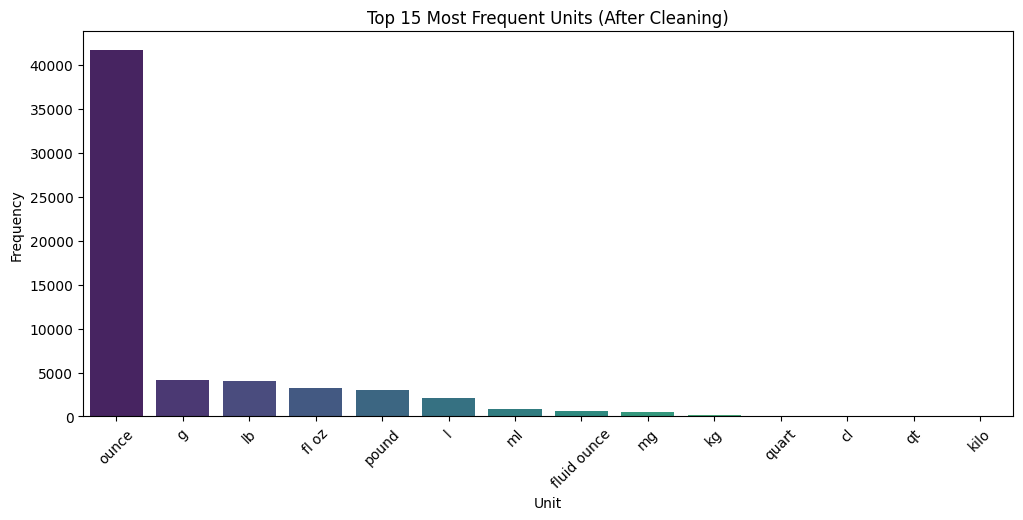

Experiemental Insight: If you see 'unit' or 'nan' as high frequency, it means extraction failed for many rows.


In [7]:
# --- Visualization: Top Units (Sanity Check) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the most common units after cleaning
plt.figure(figsize=(12, 5))
top_units = df['unit'].value_counts().head(15)
sns.barplot(x=top_units.index, y=top_units.values, palette='viridis')
plt.title('Top 15 Most Frequent Units (After Cleaning)')
plt.xlabel('Unit')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

print("Experiemental Insight: If you see 'unit' or 'nan' as high frequency, it means extraction failed for many rows.")

In [8]:
df.head()

,sample_id,catalog_content,image_link,price,item_size,unit,pack_count,total_quantity
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,12.00,ounce,6.0,72.00
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,8.00,ounce,4.0,32.00
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,1.90,ounce,1.0,1.90
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,11.25,ounce,1.0,11.25
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,12.70,ounce,1.0,12.70


In [9]:
import pandas as pd
from sklearn.model_selection import KFold

# Assuming 'df' is your DataFrame

# --- 1. Drop the unnecessary 'quantity' column ---
if 'quantity' in df.columns:
    df = df.drop(columns=['quantity'])
    print("Dropped the 'quantity' column.")

# --- 2. Apply Cross-Validated Target Encoding ---
print("\nApplying advanced target encoding to the 'unit' column...")

# Define the target and the categorical feature
target_col = 'price'
categorical_col = 'unit'

# Create a new column to store the encoded values, initialized with zeros
df['unit_target_encoded'] = 0.0

# Set up cross-validation with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Loop through each fold
for fold, (train_index, val_index) in enumerate(kf.split(df)):
    print(f"Processing fold {fold+1}/5...")
    
    # Split the data for this fold
    df_train, df_val = df.iloc[train_index], df.iloc[val_index]
    
    # Calculate the average price for each unit *only on the training part of the fold*
    target_mean_map = df_train.groupby(categorical_col)[target_col].mean()
    
    # Apply this average to the validation part of the fold
    df.loc[val_index, 'unit_target_encoded'] = df_val[categorical_col].map(target_mean_map)

# Handle any units in the full dataset that were rare and might not have appeared in a training fold
# We fill them with the global average price.
global_mean = df[target_col].mean()
df['unit_target_encoded'].fillna(global_mean, inplace=True)


# --- 3. Check Your Work ---
print("\n✅ Target encoding complete.")
print("Showing the original 'unit' and the new powerful 'unit_target_encoded' feature:")



Applying advanced target encoding to the 'unit' column...
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...

✅ Target encoding complete.
Showing the original 'unit' and the new powerful 'unit_target_encoded' feature:


C:\Users\nikk6\AppData\Local\Temp\ipykernel_25444\2285809252.py:40: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['unit_target_encoded'].fillna(global_mean, inplace=True)


In [ ]:
# --- Visualization: Feature Impact & Correlations ---
plt.figure(figsize=(18, 5))

# 1. Price vs. Total Quantity (Log-Log Scale)
plt.subplot(1, 3, 1)
# Filter for positive values to avoid log errors
plot_df = df[(df['total_quantity'] > 0) & (df['price'] > 0)].sample(min(2000, len(df)), random_state=42)
sns.scatterplot(x=np.log1p(plot_df['total_quantity']), y=np.log1p(plot_df['price']), alpha=0.4, color='dodgerblue')
plt.title('Does "More" cost "More"?\n(Log Qty vs Log Price)')
plt.xlabel('Log(Total Quantity)')
plt.ylabel('Log(Price)')

# 2. Target Encoding Effectiveness
plt.subplot(1, 3, 2)
# We expect the encoded value (mean price of unit) to correlate with actual price
sns.scatterplot(x=np.log1p(plot_df['unit_target_encoded']), y=np.log1p(plot_df['price']), alpha=0.4, color='purple')
plt.title('Target Encoding Power\n(Encoded Unit Value vs Actual Price)')
plt.xlabel('Log(Unit Target Encoded)')
plt.ylabel('Log(Price)')

# 3. Correlation Matrix
plt.subplot(1, 3, 3)
numeric_cols = ['price', 'total_quantity', 'item_size', 'pack_count', 'unit_target_encoded']
# Ensure columns exist
available_cols = [c for c in numeric_cols if c in df.columns]
corr = df[available_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlations')

plt.tight_layout()
plt.show()

print("Experimental Insight:")
print("1. Middle Plot: If this is a straight diagonal line, your target encoding is working perfectly (maybe too well -> overfitting risk?).")
print("2. Right Plot: Look for high correlation between 'unit_target_encoded' and 'price'. That's your most powerful feature.")

In [10]:
# import pandas as pd
# import re
# from collections import Counter
# import spacy

# def extract_brands_optimized(df):
#     """
#     An optimized function to extract brand names using a combination of
#     vectorized pandas operations and batched NLP processing with spaCy.
#     """
#     # FIX: Ensure the entire column is a string type
#     df['catalog_content'] = df['catalog_content'].astype(str)

#     # --- A: Build Brand List (Optimized & Vectorized) ---
#     print("Building brand list from the dataset (optimized)...")
#     name_series = df['catalog_content'].str.split('Item Name: ', n=1, expand=True)[1].fillna('')
#     words = name_series.str.split(n=3)
#     one_words, two_words, three_words = words.str[0], words.str[:2].str.join(' '), words.str[:3].str.join(' ')
#     word_counts = Counter(one_words) + Counter(two_words) + Counter(three_words)
#     brands_from_data = {word for word, count in word_counts.items() if count > 5 and len(word) > 2}
#     sorted_brands = sorted(list(brands_from_data), key=len, reverse=True)
#     print(f"Found {len(sorted_brands)} potential brands.")

#     # --- B: Extract Brands in Stages (Vectorized First) ---
#     print("\nExtracting brands...")
#     df['brand'] = None
#     for brand in sorted_brands:
#         mask = (df['brand'].isnull()) & (df['catalog_content'].str.lower().str.startswith(f"item name: {brand.lower()}", na=False))
#         df.loc[mask, 'brand'] = brand
#     print(f"{(~df['brand'].isnull()).sum()} brands identified from frequency list.")

#     # --- C: Use Batched NLP for Remaining Rows ---
#     remaining_indices = df[df['brand'].isnull()].index
#     if not remaining_indices.empty:
#         print(f"Using spaCy on the remaining {len(remaining_indices)} items...")
#         nlp = spacy.load("en_core_web_sm")
#         texts_to_process = df.loc[remaining_indices, 'catalog_content'].str.split('Item Name: ', n=1, expand=True)[1].fillna('')
#         docs = nlp.pipe(texts_to_process, disable=["tok2vec", "parser", "attribute_ruler", "lemmatizer"])
#         for i, doc in enumerate(docs):
#             for ent in doc.ents:
#                 if ent.label_ in ["ORG", "PRODUCT"]:
#                     df.loc[remaining_indices[i], 'brand'] = ent.text
#                     break

#     # --- D: Vectorized Fallback ---
#     remaining_mask = df['brand'].isnull()
#     if remaining_mask.any():
#         df.loc[remaining_mask, 'brand'] = df.loc[remaining_mask, 'catalog_content'].str.split('Item Name: ', n=1, expand=True)[1].str.split(' ', n=1, expand=True)[0]

#     df['brand'].fillna("unknown", inplace=True)
#     return df

# # --- E: Apply the Function and SAVE THE RESULT ---
# # This is the corrected line:
# df = extract_brands_optimized(df.copy())

# # --- F: Check Your Work ---
# print("\n--- Brand Extraction Results ---")
# # The 'brand' column will now exist
# print(df[['catalog_content', 'brand']].head(20))

In [11]:
df.head()

,sample_id,catalog_content,image_link,price,item_size,unit,pack_count,total_quantity,unit_target_encoded
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,12.00,ounce,6.0,72.00,19.839793
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,8.00,ounce,4.0,32.00,19.839793
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,1.90,ounce,1.0,1.90,19.674755
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,11.25,ounce,1.0,11.25,19.839793
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,12.70,ounce,1.0,12.70,19.762018


In [12]:
df[df['sample_id'] == 9259]

,sample_id,catalog_content,image_link,price,item_size,unit,pack_count,total_quantity,unit_target_encoded
5,9259,"Item Name: Member's Mark Member's Mark, Basil,...",https://m.media-amazon.com/images/I/81nw0HXpCR...,18.5,6.25,ounce,1.0,6.25,19.674755


In [13]:
##1

In [14]:
##2

In [15]:
##3

In [16]:
# This will display an array of all unique values in the 'unit' column
# df['unit'].unique()

In [17]:
# # Assuming 'df' is your DataFrame with the 'unit' column

# # 1. Create the replacement dictionary
# unit_replacement_map = {
#     'oz': 'ounce',
#     'milliliter': 'ml',
#     'milliliters': 'ml', # Adding plural form for completeness
#     'piece': 'pc',
#     'pieces': 'pc',     # Adding plural
#     'pack': 'pack of',
#     'set': 'set of',       # Adding a similar unit for consistency
#     'milligrams': 'mg',
#     'kilograms': 'kg',
#     'feet': 'ft'
# }

# # 2. Apply the replacements to the 'unit' column
# print("Replacing values in the 'unit' column...")
# df['unit'] = df['unit'].replace(unit_replacement_map)

# # 3. Check your work to confirm the changes
# print("\nUnique values in the 'unit' column after replacement:")
# print(df['unit'].unique())

In [18]:
df.head()

,sample_id,catalog_content,image_link,price,item_size,unit,pack_count,total_quantity,unit_target_encoded
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,12.00,ounce,6.0,72.00,19.839793
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,8.00,ounce,4.0,32.00,19.839793
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,1.90,ounce,1.0,1.90,19.674755
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,11.25,ounce,1.0,11.25,19.839793
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,12.70,ounce,1.0,12.70,19.762018


In [19]:
# import pandas as pd
# from sklearn.model_selection import KFold

# # Assuming 'df' is your DataFrame

# # --- 1. Drop the unnecessary 'quantity' column ---
# if 'quantity' in df.columns:
#     df = df.drop(columns=['quantity'])
#     print("Dropped the 'quantity' column.")

# # --- 2. Apply Cross-Validated Target Encoding ---
# print("\nApplying advanced target encoding to the 'unit' column...")

# # Define the target and the categorical feature
# target_col = 'price'
# categorical_col = 'unit'

# # Create a new column to store the encoded values, initialized with zeros
# df['unit_target_encoded'] = 0.0

# # Set up cross-validation with 5 folds
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Loop through each fold
# for fold, (train_index, val_index) in enumerate(kf.split(df)):
#     print(f"Processing fold {fold+1}/5...")
    
#     # Split the data for this fold
#     df_train, df_val = df.iloc[train_index], df.iloc[val_index]
    
#     # Calculate the average price for each unit *only on the training part of the fold*
#     target_mean_map = df_train.groupby(categorical_col)[target_col].mean()
    
#     # Apply this average to the validation part of the fold
#     df.loc[val_index, 'unit_target_encoded'] = df_val[categorical_col].map(target_mean_map)

# # Handle any units in the full dataset that were rare and might not have appeared in a training fold
# # We fill them with the global average price.
# global_mean = df[target_col].mean()
# df['unit_target_encoded'].fillna(global_mean, inplace=True)


# # --- 3. Check Your Work ---
# print("\n✅ Target encoding complete.")
# print("Showing the original 'unit' and the new powerful 'unit_target_encoded' feature:")
# print(df[['unit', 'price', 'unit_target_encoded']].head(10))

In [20]:
df.head(10)

,sample_id,catalog_content,image_link,price,item_size,unit,pack_count,total_quantity,unit_target_encoded
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,12.00,ounce,6.0,72.00,19.839793
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,8.00,ounce,4.0,32.00,19.839793
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,1.90,ounce,1.0,1.90,19.674755
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,11.25,ounce,1.0,11.25,19.839793
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,12.70,ounce,1.0,12.70,19.762018
5,9259,"Item Name: Member's Mark Member's Mark, Basil,...",https://m.media-amazon.com/images/I/81nw0HXpCR...,18.50,6.25,ounce,1.0,6.25,19.674755
6,191846,Item Name: Goya Foods Sazonador Total Seasonin...,https://m.media-amazon.com/images/I/61dH2Ebkt0...,5.99,30.00,ounce,6.0,180.00,19.726170
7,222007,Item Name: VineCo Original Series Chilean Sauv...,https://m.media-amazon.com/images/I/71JllaFpxM...,94.00,8.00,l,2.0,16.00,41.951829
8,37614,Item Name: NATURES PATH CEREAL FLK MULTIGRAIN ...,https://m.media-amazon.com/images/I/21O9RftI2v...,35.74,32.00,ounce,6.0,192.00,19.734479
9,238044,Item Name: Mrs. Miller's Seedless Black Raspbe...,https://m.media-amazon.com/images/I/41miQk+RkJ...,31.80,9.00,ounce,4.0,36.00,19.839793


In [21]:
df[df['sample_id'] == 186165]

,sample_id,catalog_content,image_link,price,item_size,unit,pack_count,total_quantity,unit_target_encoded
48,186165,Item Name: Seasons Brand Imported Skinless & B...,https://m.media-amazon.com/images/I/41HJmvLaTy...,2.54,4.25,ounce,1.0,4.25,19.674755


In [22]:
# --- 5. Save the Processed Training Data ---

# Define the path for the output file
# The '../' correctly navigates up from the 'notebooks' folder to the project root
train_processed_path = os.path.join('..', 'data', 'processed', 'train_features_text.csv')

# Save the DataFrame to a CSV file
print(f"Saving processed training data to: {train_processed_path}")
df.to_csv(train_processed_path, index=False)

print("✅ Training data saved successfully.")

Saving processed training data to: ..\data\processed\train_features_text.csv
✅ Training data saved successfully.


In [23]:
# --- 6. Process and Save the Test Data ---

print("Processing test data...")

# --- Load the raw test data ---
test_raw_path = os.path.join('..', 'data', 'raw', 'test.csv')
test_df = pd.read_csv(test_raw_path)

# --- Apply the EXACT SAME feature engineering functions from the training phase ---
temp_test_df = test_df['catalog_content'].apply(extract_item_size_and_unit).apply(pd.Series)
test_df['item_size'] = temp_test_df[0]
test_df['unit'] = temp_test_df[1]

# Use the improved pack count function
test_df['pack_count'] = test_df['catalog_content'].apply(extract_pack_count_final_v2)

# --- Clean up and create the final feature ---
test_df['item_size'].fillna(1.0, inplace=True)
test_df['unit'].fillna('unit', inplace=True)
test_df['total_quantity'] = test_df['item_size'] * test_df['pack_count']

# --- Reorder columns to match training output ---
final_columns = ['sample_id', 'catalog_content', 'image_link', 'price',
                 'item_size', 'pack_count', 'total_quantity', 'unit']
final_columns = [col for col in final_columns if col in test_df.columns]
test_df = test_df[final_columns]

# --- Save the processed test data ---
test_processed_path = os.path.join('..', 'data', 'processed', 'test_features_text.csv')
print(f"Saving processed test data to: {test_processed_path}")
test_df.to_csv(test_processed_path, index=False)

print("✅ Test data saved successfully.")
print(test_df[['catalog_content', 'item_size', 'pack_count']].head())


Processing test data...


C:\Users\nikk6\AppData\Local\Temp\ipykernel_25444\3953716232.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  test_df['item_size'].fillna(1.0, inplace=True)
C:\Users\nikk6\AppData\Local\Temp\ipykernel_25444\3953716232.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

Saving processed test data to: ..\data\processed\test_features_text.csv
✅ Test data saved successfully.
                                     catalog_content  item_size  pack_count
0  Item Name: Rani 14-Spice Eshamaya's Mango Chut...       10.5         1.0
1  Item Name: Natural MILK TEA Flavoring extract ...        2.0         1.0
2  Item Name: Honey Filled Hard Candy - Bulk Pack...        2.0         2.0
3  Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...       16.0         2.0
4  Item Name: McCormick Culinary Vanilla Extract,...       32.0         1.0


In [24]:
df.head()

,sample_id,catalog_content,image_link,price,item_size,unit,pack_count,total_quantity,unit_target_encoded
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,12.00,ounce,6.0,72.00,19.839793
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,8.00,ounce,4.0,32.00,19.839793
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,1.90,ounce,1.0,1.90,19.674755
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,11.25,ounce,1.0,11.25,19.839793
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,12.70,ounce,1.0,12.70,19.762018
